In [3]:
from __future__ import annotations

from pathlib import Path
import logging
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from concurrent.futures import ThreadPoolExecutor
from joblib import Parallel, delayed, parallel_backend

# This JAX message is irrelevant here because this analysis intentionally runs on CPU.
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
import nemos as nmo


def find_repo_root(start: str | Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()
    for path in [start, *start.parents]:
        if (path / "setup.py").exists() and (path / "src").exists():
            return path
        candidate = path / "ZhaoLab-analysis-python"
        if (candidate / "setup.py").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Cannot find repository root containing setup.py and src/.")


REPO_ROOT = find_repo_root()
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from HPC_2P_analysis.utils.config import get_one_index, select_files  # noqa: E402
from HPC_2P_analysis.utils.loadData import load_screen_data  # noqa: E402

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"SRC_ROOT  = {SRC_ROOT}")

REPO_ROOT = /home/wangym/code/ZhaoLab-analysis-python
SRC_ROOT  = /home/wangym/code/ZhaoLab-analysis-python/src


In [4]:
# =============================================================================
# Configuration
# =============================================================================

DATA_ROOT = REPO_ROOT / "data" / "HPC_2p" / "screen"
TASK_TYPES = ("pattern", "position")
REWARD_MODE = "full"
# Use the unmasked attracted_data stored in each screen pickle, then construct a
# new zone-2/zone-4-specific screening mask below. This prevents the original
# whole-track mask from determining the candidate population for this GLM.
SCREEN_MODE = "raw"
BEHAVIOR_NAME = "Correct"
SESSION_POLICY = "latest"

# "default": cue + position + reward when reward is identifiable.
# "reduced": cue + position only.
GLM_MODEL = "default"  # "default" or "reduced"

# Fit mixed C1/C3/C5 and C-separated models.
ANALYSIS_MODES = ("mixed", "by_c_position")

# Do not re-standardize activity: firing is already upstream z-scored.
# Keep False so GLM uses the same zone-average activity scale as the other analyses.
MIN_OBS = 8
BALANCE_EPS = 1e-12

# Zone 2/4-specific neuron screening. This reproduces the final neuron_selection
# procedure but limits each condition's spatial candidate bins to the
# concatenated canonical zone-2 and zone-4 intervals.
ZONE24_SCREEN_MIN_TRIALS = 10
ZONE24_SCREEN_WINSOR_N = 1
ZONE24_SCREEN_N_PERM = 5000
ZONE24_SCREEN_ALPHA = 0.01
ZONE24_SCREEN_BASELINE = "median"
ZONE24_SCREEN_ALTERNATIVE = "two-sided"
ZONE24_SCREEN_RULE_CORRECTION = "bonferroni"
ZONE24_SCREEN_SEED = 0
FILE_N_JOBS = 32
TRACK_N_JOBS = 32  # parallel track permutations inside each file

RULE_COLORS = {
    "pattern": "#6BA3D6",
    "position": "#F0B35B",
}
RULE_LABELS = {
    "pattern": "Pattern rule",
    "position": "Position rule",
}
COEF_LABELS = {
    "cue_ab": "A/B cue selectivity",
    "zone_position": "Zone 2/4 position selectivity",
    "reward_prepost": "Pre/post reward-site coefficient",
}

print(f"DATA_ROOT = {DATA_ROOT}")
print(f"GLM_MODEL = {GLM_MODEL}")

DATA_ROOT = /home/wangym/code/ZhaoLab-analysis-python/data/HPC_2p/screen
GLM_MODEL = default


In [5]:
# =============================================================================
# File selection
# =============================================================================

def extract_session_date_from_name(name: str | Path) -> str | None:
    name = Path(name).name
    match = re.search(r"(?<!\d)((?:19|20)\d{2})[-_]?([01]\d)[-_]?([0-3]\d)(?!\d)", name)
    if match is not None:
        year, month, day = match.groups()
        return f"{year}-{month}-{day}"
    match = re.search(r"(?<!\d)(\d{2})([01]\d)([0-3]\d)(?!\d)", name)
    if match is not None:
        yy, month, day = match.groups()
        return f"20{yy}-{month}-{day}"
    return None


def infer_mouse_base_id(text: str | Path | None) -> str | None:
    if text is None:
        return None
    text = Path(text).name if isinstance(text, Path) else str(text)
    match = re.search(r"\b(HPC?\d+)\b", text, flags=re.IGNORECASE)
    return None if match is None else match.group(1).upper()


def add_session_columns(file_df: pd.DataFrame) -> pd.DataFrame:
    file_df = file_df.copy()
    session_dates = []
    mouse_base_ids = []
    for _, row in file_df.iterrows():
        candidates = [row.get("mouse_id"), row.get("file_name"), row.get("source_stem"), row.get("file_path")]
        session_date = None
        mouse_base_id = None
        for candidate in candidates:
            if candidate is None:
                continue
            if session_date is None:
                session_date = extract_session_date_from_name(candidate)
            if mouse_base_id is None:
                mouse_base_id = infer_mouse_base_id(candidate)
        session_dates.append(session_date)
        mouse_base_ids.append(mouse_base_id if mouse_base_id is not None else row.get("mouse_id"))
    file_df["session_date"] = session_dates
    file_df["session_key"] = file_df["session_date"].str.replace("-", "", regex=False)
    file_df["mouse_base_id"] = mouse_base_ids
    return file_df


def select_one_session_per_mouse_task(file_df: pd.DataFrame, *, session_policy: str = SESSION_POLICY) -> pd.DataFrame:
    file_df = add_session_columns(file_df)
    if session_policy in {"none", None}:
        return file_df.reset_index(drop=True)
    if session_policy not in {"latest", "earliest"}:
        raise ValueError("session_policy must be 'latest', 'earliest', or 'none'.")
    if file_df["session_key"].isna().any():
        bad = file_df.loc[file_df["session_key"].isna(), ["file_path", "file_name", "mouse_id"]]
        raise ValueError("Some files have no parseable session date:\n" + bad.to_string(index=False))

    group_cols = ["mouse_base_id", "task_type"]
    if "reward_mode" in file_df.columns:
        group_cols.append("reward_mode")
    sorted_df = file_df.sort_values(group_cols + ["session_key", "file_name"])
    selected = sorted_df.groupby(group_cols, as_index=False, group_keys=False).tail(1) if session_policy == "latest" else sorted_df.groupby(group_cols, as_index=False, group_keys=False).head(1)
    print(f"[Session selection] policy={session_policy}, input={len(file_df)}, selected={len(selected)}")
    return selected.reset_index(drop=True)


def load_pattern_position_file_table(data_root: str | Path = DATA_ROOT) -> pd.DataFrame:
    file_df = select_files(
        data_root,
        task_type=TASK_TYPES,
        reward_mode=REWARD_MODE,
        file_kind="pickle",
        recursive=True,
    )
    if len(file_df) == 0:
        raise ValueError(f"No screen pickle files found under {data_root}")
    file_df = select_one_session_per_mouse_task(file_df, session_policy=SESSION_POLICY)
    display_cols = ["mouse_base_id", "mouse_id", "task_type", "reward_mode", "session_date", "file_name", "file_path"]
    display(file_df[[c for c in display_cols if c in file_df.columns]])
    return file_df

In [6]:
# =============================================================================
# Task semantics and zone helpers
# =============================================================================

C_POSITION_TRACKS = {
    1: ("CAB", "CBA"),
    3: ("ACB", "BCA"),
    5: ("ABC", "BAC"),
}
DESTINATION_TRACKS = tuple(track for c in (1, 3, 5) for track in C_POSITION_TRACKS[c])


def first_number(x) -> float:
    values = np.asarray(x).ravel()
    if len(values) < 2:
        raise ValueError(f"Each zone must contain at least two bounds, got {values}.")
    return float(values[0])


def second_number(x) -> float:
    values = np.asarray(x).ravel()
    if len(values) < 2:
        raise ValueError(f"Each zone must contain at least two bounds, got {values}.")
    return float(values[1])


def get_zone_interval(zones, zone_index: int, n_position: int) -> tuple[int, int]:
    start = int(np.floor(first_number(zones[zone_index])))
    end = int(np.ceil(second_number(zones[zone_index])))
    start = int(np.clip(start, 0, n_position))
    end = int(np.clip(end, 0, n_position))
    if end <= start:
        raise ValueError(f"Invalid zone interval: zone_index={zone_index}, interval=({start}, {end}).")
    return start, end


def get_similarity_zone_bounds(data: dict, n_position: int) -> tuple[int, int, int, int]:
    # Canonical interval mode from similarity_analysis.ipynb.
    s1, e1 = get_zone_interval(data["zones"], 1, n_position)  # zone 2
    s2, e2 = get_zone_interval(data["zones"], 3, n_position)  # zone 4
    return s1, e1, s2, e2


def track_to_c_position(track_name: str) -> int:
    base = str(track_name).replace("couple_", "")
    if base in {"CAB", "CBA"}:
        return 1
    if base in {"ACB", "BCA"}:
        return 3
    if base in {"ABC", "BAC"}:
        return 5
    raise ValueError(f"Unknown destination track: {track_name!r}")


def track_to_direction(track_name: str) -> str:
    base = str(track_name).replace("couple_", "")
    if base in {"CAB", "ACB", "ABC"}:
        return "AB"
    if base in {"CBA", "BCA", "BAC"}:
        return "BA"
    raise ValueError(f"Unknown destination track: {track_name!r}")


def cue_at_zone(track_name: str, zone_label: int) -> str:
    direction = track_to_direction(track_name)
    if zone_label == 2:
        return "A" if direction == "AB" else "B"
    if zone_label == 4:
        return "B" if direction == "AB" else "A"
    raise ValueError("zone_label must be 2 or 4.")


def reward_position_for_track(task_type: str, track_name: str) -> int:
    if task_type == "pattern":
        return track_to_c_position(track_name)
    if task_type == "position":
        return 3
    raise ValueError("Only pattern and position are supported here.")


def reward_state_for_zone(task_type: str, track_name: str, zone_label: int) -> str:
    reward_position = reward_position_for_track(task_type, track_name)
    if zone_label < reward_position:
        return "pre"
    if zone_label > reward_position:
        return "post"
    return "at_reward"


def get_firing_for_track_behavior(data: dict, track_name: str, behavior_name: str = BEHAVIOR_NAME) -> np.ndarray:
    tt_idx, bt_idx = get_one_index(data, track_name, behavior_name)
    fr = data["firing"][tt_idx, bt_idx]
    if fr is None:
        return np.empty((0, 0, 0))
    return np.asarray(fr, dtype=float)

In [7]:
# =============================================================================
# Build trial-zone observation table
# =============================================================================

def build_zone24_observation_table(
    data: dict,
    *,
    task_type: str,
    behavior_name: str = BEHAVIOR_NAME,
    tracks: tuple[str, ...] = DESTINATION_TRACKS,
) -> tuple[np.ndarray, pd.DataFrame]:
    """Return Y observations and design metadata.

    Y has shape (n_observation, n_neuron). Each trial contributes one zone-2
    observation and one zone-4 observation.
    """
    y_rows = []
    meta_rows = []
    n_neuron_ref = None

    for track_name in tracks:
        fr = get_firing_for_track_behavior(data, track_name, behavior_name)
        if fr.ndim != 3:
            raise ValueError(f"Expected 3D firing for track={track_name!r}, got shape {fr.shape}.")
        if fr.shape[1] == 0:
            continue
        if n_neuron_ref is None:
            n_neuron_ref = fr.shape[0]
        elif fr.shape[0] != n_neuron_ref:
            raise ValueError("Neuron count differs across tracks in one session.")

        n_position = fr.shape[2]
        s1, e1, s2, e2 = get_similarity_zone_bounds(data, n_position)
        c_position = track_to_c_position(track_name)
        direction = track_to_direction(track_name)

        for zone_label, start, end in [(2, s1, e1), (4, s2, e2)]:
            y_zone = np.nanmean(fr[:, :, start:end], axis=2).T  # n_trial x n_neuron
            cue = cue_at_zone(track_name, zone_label)
            reward_state = reward_state_for_zone(task_type, track_name, zone_label)
            for trial_idx in range(y_zone.shape[0]):
                y_rows.append(y_zone[trial_idx])
                meta_rows.append({
                    "track": track_name,
                    "direction": direction,
                    "trial_idx": trial_idx,
                    "zone_label": zone_label,
                    "c_position": c_position,
                    "c_group": f"C{c_position}",
                    "cue": cue,
                    "reward_state": reward_state,
                    "cue_ab": -0.5 if cue == "A" else 0.5,
                    "zone_position": -0.5 if zone_label == 2 else 0.5,
                    "reward_prepost": -0.5 if reward_state == "pre" else 0.5,
                })

    if len(y_rows) == 0:
        raise ValueError("No zone 2/4 observations were constructed.")
    return np.vstack(y_rows).astype(float), pd.DataFrame(meta_rows)


def subset_observations(
    Y: np.ndarray,
    obs: pd.DataFrame,
    *,
    analysis_mode: str,
    c_position: int | None = None,
) -> tuple[np.ndarray, pd.DataFrame, str]:
    if analysis_mode == "mixed":
        return Y, obs.copy(), "mixed"
    if analysis_mode == "by_c_position":
        if c_position not in {1, 3, 5}:
            raise ValueError("c_position must be 1, 3, or 5 for by_c_position.")
        mask = obs["c_position"].to_numpy() == c_position
        return Y[mask], obs.loc[mask].reset_index(drop=True), f"C{c_position}"
    raise ValueError("analysis_mode must be 'mixed' or 'by_c_position'.")

# =============================================================================
# Zone 2/4-specific neuron selection (same test logic as neuron_selection.ipynb)
# =============================================================================

def _winsorize_trials(x: np.ndarray, winsor_n: int) -> np.ndarray:
    if winsor_n <= 0:
        return x.astype(float, copy=True)
    n_trial = x.shape[1]
    if 2 * winsor_n >= n_trial:
        raise ValueError(f"winsor_n={winsor_n} is invalid for n_trial={n_trial}.")
    sorted_x = np.sort(x, axis=1)
    lo = np.take(sorted_x, winsor_n, axis=1)[:, None, :]
    hi = np.take(sorted_x, n_trial - winsor_n - 1, axis=1)[:, None, :]
    return np.clip(x, lo, hi)


def _two_zone_t_map(x: np.ndarray, winsor_n: int, std_floor: float = 1e-8) -> np.ndarray:
    """t-like map for exactly two observations per trial: [zone2, zone4]."""
    xw = _winsorize_trials(x, winsor_n)
    mean = np.mean(xw, axis=1)
    std = np.std(xw, axis=1, ddof=1)
    return mean / (np.maximum(std, std_floor) / np.sqrt(x.shape[1]))


def _max_t(t_map: np.ndarray, alternative: str) -> np.ndarray:
    if alternative == "greater":
        return np.max(t_map, axis=1)
    if alternative == "less":
        return -np.min(t_map, axis=1)
    if alternative == "two-sided":
        return np.max(np.abs(t_map), axis=1)
    raise ValueError("alternative must be 'greater', 'less', or 'two-sided'.")




def _screen_one_zone24_condition(
    fr_centered: np.ndarray,
    zone_bounds: tuple[int, int, int, int],
    *,
    min_trials: int,
    winsor_n: int,
    n_perm: int,
    alpha: float,
    alternative: str,
    seed: int,
) -> dict:
    """Screen one track after merging zone 2 and zone 4 separately.

    The observed statistic is the maximum of the two zone-level t-like values.
    Under the null, each neuron-trial full-track curve is circularly shifted
    before the same two fixed zones are averaged. No correction across neurons
    is applied here.
    """
    n_neuron, n_trial, n_position = fr_centered.shape
    s2, e2, s4, e4 = zone_bounds
    empty = {
        "p_values": np.full(n_neuron, np.nan),
        "mask": np.zeros(n_neuron, dtype=bool),
        "skipped": True,
        "skip_reason": None,
        "n_trial": n_trial,
        "n_candidate_zones": 2,
        "null_method": "full_track_circular_shift_max_t",
    }
    if n_trial < min_trials:
        empty["skip_reason"] = f"n_trial={n_trial} < min_trials={min_trials}"
        return empty
    if np.isnan(fr_centered).any():
        empty["skip_reason"] = "NaN in full-track firing"
        return empty

    zone2 = np.mean(fr_centered[:, :, s2:e2], axis=2)
    zone4 = np.mean(fr_centered[:, :, s4:e4], axis=2)
    zone_values = np.stack([zone2, zone4], axis=2)
    observed = _max_t(_two_zone_t_map(zone_values, winsor_n), alternative)

    rng = np.random.default_rng(seed)
    exceed = np.zeros(n_neuron, dtype=int)
    zone2_idx = np.arange(s2, e2)[None, None, :]
    zone4_idx = np.arange(s4, e4)[None, None, :]
    for _ in range(n_perm):
        shifts = rng.integers(0, n_position, size=(n_neuron, n_trial))
        # Gather only bins that land in zone 2/4 after shifting. This is
        # equivalent to shifting the full track, but avoids allocating it.
        idx2 = (zone2_idx - shifts[:, :, None]) % n_position
        idx4 = (zone4_idx - shifts[:, :, None]) % n_position
        perm_zone2 = np.mean(np.take_along_axis(fr_centered, idx2, axis=2), axis=2)
        perm_zone4 = np.mean(np.take_along_axis(fr_centered, idx4, axis=2), axis=2)
        perm_values = np.stack([perm_zone2, perm_zone4], axis=2)
        perm = _max_t(_two_zone_t_map(perm_values, winsor_n), alternative)
        exceed += perm >= observed

    p_values = (exceed + 1) / (n_perm + 1)
    return {
        "p_values": p_values,
        "mask": p_values < alpha,
        "t_max": observed,
        "skipped": False,
        "skip_reason": None,
        "n_trial": n_trial,
        "n_candidate_zones": 2,
        "null_method": "full_track_circular_shift_max_t",
    }


def _screen_zone24_track(
    data: dict,
    task_type: str,
    track_name: str,
    behavior_name: str,
    kwargs: dict,
    seed: int,
) -> tuple[str, dict]:
    fr = get_firing_for_track_behavior(data, track_name, behavior_name)
    if fr.ndim != 3:
        raise ValueError(f"Expected 3D firing for {track_name!r}, got {fr.shape}.")
    zone_bounds = get_similarity_zone_bounds(data, fr.shape[2])
    baseline_method = kwargs.get("baseline_method")
    if baseline_method == "median":
        fr_centered = fr - np.nanmedian(fr, axis=2, keepdims=True)
    elif baseline_method == "mean":
        fr_centered = fr - np.nanmean(fr, axis=2, keepdims=True)
    elif baseline_method == "none":
        fr_centered = fr.astype(float, copy=True)
    else:
        raise ValueError("baseline_method must be 'median', 'mean', or 'none'.")

    condition_kwargs = dict(kwargs)
    condition_kwargs.pop("baseline_method", None)
    return track_name, _screen_one_zone24_condition(
        fr_centered,
        zone_bounds,
        seed=seed,
        **condition_kwargs,
    )


def screen_zone24_neurons(
    data: dict,
    *,
    task_type: str,
    tracks: tuple[str, ...] = DESTINATION_TRACKS,
    behavior_name: str = BEHAVIOR_NAME,
    min_trials: int = ZONE24_SCREEN_MIN_TRIALS,
    winsor_n: int = ZONE24_SCREEN_WINSOR_N,
    n_perm: int = ZONE24_SCREEN_N_PERM,
    alpha: float = ZONE24_SCREEN_ALPHA,
    baseline_method: str = ZONE24_SCREEN_BASELINE,
    alternative: str = ZONE24_SCREEN_ALTERNATIVE,
    rule_correction: str = ZONE24_SCREEN_RULE_CORRECTION,
    seed: int = ZONE24_SCREEN_SEED,
    n_jobs: int = TRACK_N_JOBS,
) -> dict:
    """Zone2/4 screening with original selection logic and direct two-zone input.

    Zone 2 and zone 4 are each averaged into one value per trial. Track
    conditions stay serial inside a file because files are parallelized outside.
    """
    kwargs = dict(
        min_trials=min_trials,
        winsor_n=winsor_n,
        n_perm=n_perm,
        alpha=alpha,
        baseline_method=baseline_method,
        alternative=alternative,
    )
    seed_rng = np.random.default_rng(seed)
    track_seeds = {track: int(seed_rng.integers(0, np.iinfo(np.int32).max)) for track in tracks}
    n_worker = min(max(1, int(n_jobs)), len(tracks))
    if n_worker == 1:
        results = [
            _screen_zone24_track(data, task_type, track, behavior_name, kwargs, track_seeds[track])
            for track in tracks
        ]
    else:
        # NumPy releases the GIL in the large gather/mean operations. Threads
        # share the loaded file and avoid copying firing arrays to child processes.
        with ThreadPoolExecutor(max_workers=n_worker) as executor:
            futures = [
                executor.submit(
                    _screen_zone24_track,
                    data,
                    task_type,
                    track,
                    behavior_name,
                    kwargs,
                    track_seeds[track],
                )
                for track in tracks
            ]
            results = [future.result() for future in futures]
    condition_results = dict(results)
    p_by_track = [condition_results[track]["p_values"] for track in tracks]
    p_matrix = np.vstack(p_by_track)
    n_neuron = p_matrix.shape[1]
    valid = np.isfinite(p_matrix)
    n_valid = valid.sum(axis=0)
    p_min = np.full(n_neuron, np.nan)
    has_valid = n_valid > 0
    p_min[has_valid] = np.nanmin(p_matrix[:, has_valid], axis=0)
    if rule_correction == "bonferroni":
        p_neuron = np.minimum(p_min * n_valid, 1.0)
    elif rule_correction == "none":
        p_neuron = p_min
    else:
        raise ValueError("rule_correction must be 'bonferroni' or 'none'.")
    final_mask = np.isfinite(p_neuron) & (n_valid > 0) & (p_neuron < alpha)
    return {
        "final_mask": final_mask,
        "p_neuron": p_neuron,
        "p_min": p_min,
        "n_valid_rules": n_valid,
        "condition_results": condition_results,
        "summary": {"n_neuron": int(n_neuron), "n_kept": int(final_mask.sum()), "keep_rate": float(final_mask.mean())},
        "params": {"candidate_zones": (2, 4), "input": "direct_trial_zone_means", "null_method": "full_track_circular_shift_max_t", "min_trials": min_trials, "winsor_n": winsor_n, "n_perm": n_perm, "alpha": alpha, "baseline_method": baseline_method, "alternative": alternative, "rule_correction": rule_correction, "seed": seed, "n_jobs": n_worker},
    }

In [8]:
# =============================================================================
# Design matrix and GLM fitting
# =============================================================================

def is_full_rank(X: np.ndarray, tol: float = 1e-10) -> bool:
    return np.linalg.matrix_rank(X, tol=tol) == X.shape[1]


def add_regressor_if_valid(columns: list[np.ndarray], names: list[str], values, name: str, omitted: list[str]) -> None:
    values = np.asarray(values, dtype=float)
    if np.nanstd(values) < 1e-10:
        omitted.append(f"{name}: constant")
        return
    proposed = np.column_stack([*columns, values])
    if not is_full_rank(proposed):
        omitted.append(f"{name}: collinear")
        return
    columns.append(values)
    names.append(name)


def make_design_matrix(obs: pd.DataFrame, *, task_type: str, model_type: str = GLM_MODEL) -> dict:
    if model_type not in {"default", "reduced"}:
        raise ValueError("GLM_MODEL/model_type must be 'default' or 'reduced'.")

    columns = [np.ones(len(obs), dtype=float)]
    names = ["intercept"]
    omitted = []

    add_regressor_if_valid(columns, names, obs["cue_ab"], "cue_ab", omitted)
    add_regressor_if_valid(columns, names, obs["zone_position"], "zone_position", omitted)

    if model_type == "default":
        if task_type == "position":
            omitted.append("reward_prepost: omitted in Position rule because it is aliased with zone_position")
        else:
            add_regressor_if_valid(columns, names, obs["reward_prepost"], "reward_prepost", omitted)

    X = np.column_stack(columns)
    return {
        "X": X,
        "names": names,
        "omitted": omitted,
        "rank": int(np.linalg.matrix_rank(X)),
        "full_rank": bool(is_full_rank(X)),
    }


def fit_nemos_population_gaussian(X: np.ndarray, Y: np.ndarray) -> np.ndarray:
    """Fit all neurons with one Gaussian PopulationGLM call.

    Parameters
    ----------
    X : array, shape (n_observation, n_term)
        Design matrix including the intercept in the first column.
    Y : array, shape (n_observation, n_neuron)
        Zone-level activity for all retained neurons.
    """
    X_features = X[:, 1:]
    init_params = (
        np.zeros((X_features.shape[1], Y.shape[1])),
        np.mean(Y, axis=0),
    )
    model = nmo.glm.PopulationGLM(
        observation_model=nmo.observation_models.GaussianObservations(),
        regularizer="UnRegularized",
    ).fit(X_features, Y, init_params=init_params)
    coef = np.asarray(model.coef_, dtype=float)
    intercept = np.asarray(model.intercept_, dtype=float).reshape(-1)
    if coef.shape != (X_features.shape[1], Y.shape[1]):
        raise ValueError(f"Unexpected nemos coefficient shape: {coef.shape}.")
    if intercept.shape != (Y.shape[1],):
        raise ValueError(f"Unexpected nemos intercept shape: {intercept.shape}.")
    return np.vstack([intercept, coef])


def fit_neuron_glm_table(
    Y: np.ndarray,
    obs: pd.DataFrame,
    *,
    file_meta: dict,
    analysis_mode: str,
    c_group: str,
    model_type: str = GLM_MODEL,
) -> pd.DataFrame:
    """Fit all neurons together, then compute neuron-wise OLS inference."""
    design = make_design_matrix(
        obs,
        task_type=file_meta["task_type"],
        model_type=model_type,
    )
    X = np.asarray(design["X"], dtype=float)
    Y = np.asarray(Y, dtype=float)
    names = design["names"]
    if Y.ndim != 2 or Y.shape[0] != X.shape[0]:
        raise ValueError(f"Y shape {Y.shape} is incompatible with X shape {X.shape}.")
    if not np.all(np.isfinite(X)) or not np.all(np.isfinite(Y)):
        raise ValueError("GLM input contains non-finite values.")
    if X.shape[0] < max(MIN_OBS, X.shape[1] + 1):
        raise ValueError("Too few observations for the GLM design.")
    if np.linalg.matrix_rank(X) < X.shape[1]:
        raise ValueError("GLM design is rank deficient.")

    beta = fit_nemos_population_gaussian(X, Y)
    fitted = X @ beta
    resid = Y - fitted
    df_resid = X.shape[0] - X.shape[1]
    sse = np.sum(resid ** 2, axis=0)
    centered = Y - np.mean(Y, axis=0, keepdims=True)
    sst = np.sum(centered ** 2, axis=0)
    r2 = np.divide(
        1.0 * (sst - sse),
        sst,
        out=np.full(Y.shape[1], np.nan),
        where=sst > 0,
    )

    xtx_inv = np.linalg.pinv(X.T @ X)
    sigma2 = sse / df_resid
    se = np.sqrt(np.diag(xtx_inv)[:, None] * sigma2[None, :])
    with np.errstate(divide="ignore", invalid="ignore"):
        t_values = beta / se
    p_values = 2.0 * stats.t.sf(np.abs(t_values), df=df_resid)

    cell_ids = np.asarray(file_meta.get("cell_ids", np.arange(Y.shape[1])))
    if len(cell_ids) != Y.shape[1]:
        raise ValueError("cell_ids length does not match the retained neuron count.")
    scalar_meta = {
        key: value
        for key, value in file_meta.items()
        if isinstance(value, (str, int, float, bool)) or value is None
    }
    rows = []
    for neuron_idx, cell_id in enumerate(cell_ids):
        valid = bool(np.isfinite(r2[neuron_idx]))
        row = {
            **scalar_meta,
            "analysis_mode": analysis_mode,
            "c_group": c_group,
            "model_type": model_type,
            "neuron_idx": neuron_idx,
            "cell_id": cell_id,
            "design_terms": ",".join(names),
            "omitted_terms": "; ".join(design["omitted"]),
            "design_rank": design["rank"],
            "valid": valid,
            "invalid_reason": "" if valid else "zero response variance",
            "fit_backend": "nemos_population_gaussian",
            "n_obs": int(X.shape[0]),
            "df_resid": int(df_resid),
            "r2": float(r2[neuron_idx]) if valid else np.nan,
        }
        for term_idx, name in enumerate(names):
            b = beta[term_idx, neuron_idx]
            s = se[term_idx, neuron_idx]
            t = t_values[term_idx, neuron_idx]
            p = p_values[term_idx, neuron_idx]
            row[f"beta_{name}"] = float(b)
            row[f"abs_beta_{name}"] = float(abs(b))
            row[f"se_{name}"] = float(s) if np.isfinite(s) else np.nan
            row[f"t_{name}"] = float(t) if np.isfinite(t) else np.nan
            row[f"p_{name}"] = float(p) if np.isfinite(p) else np.nan
        rows.append(row)
    return add_selectivity_balance_columns(pd.DataFrame(rows))


def add_selectivity_balance_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if {"abs_beta_cue_ab", "abs_beta_zone_position"}.issubset(df.columns):
        cue = df["abs_beta_cue_ab"].to_numpy(float)
        pos = df["abs_beta_zone_position"].to_numpy(float)
        df["selectivity_balance_cue_minus_position"] = cue - pos
        df["selectivity_balance_index"] = (cue - pos) / (cue + pos + BALANCE_EPS)
    return df


In [9]:
# =============================================================================
# Batch analysis and summaries
# =============================================================================

def make_file_meta(file_row: pd.Series, data: dict) -> dict:
    meta = dict(data.get("file_info", {}))
    for col, value in file_row.items():
        meta[col] = value
    if "mouse_base_id" not in meta or pd.isna(meta.get("mouse_base_id")):
        meta["mouse_base_id"] = infer_mouse_base_id(meta.get("mouse_id")) or meta.get("mouse_id")
    meta["cell_ids"] = np.asarray(data.get("cell_ids", []))
    return meta


def analyze_one_file(file_row: pd.Series, *, seed: int = ZONE24_SCREEN_SEED) -> pd.DataFrame:
    file_path = Path(file_row["file_path"])
    data = load_screen_data(file_path, screen_mode=SCREEN_MODE)
    file_meta = make_file_meta(file_row, data)
    task_type = file_meta["task_type"]
    print(f"[{file_path.name}] [Start] mouse={file_meta.get('mouse_base_id')} | task={task_type} | session={file_meta.get('session_date')}")

    file_tag = f"[{file_path.name}]"
    zone24_screening = screen_zone24_neurons(
        data,
        task_type=task_type,
        seed=seed,
        n_jobs=TRACK_N_JOBS,
    )
    zone24_mask = zone24_screening["final_mask"]
    if not np.any(zone24_mask):
        raise ValueError(f"{file_tag} Zone2/4 screening retained zero neurons.")
    original_cell_ids = np.asarray(file_meta["cell_ids"])
    file_meta["cell_ids"] = original_cell_ids[zone24_mask]
    file_meta["zone24_screen_n_input"] = int(len(zone24_mask))
    file_meta["zone24_screen_n_kept"] = int(zone24_mask.sum())
    file_meta["zone24_screen_keep_rate"] = float(zone24_mask.mean())
    file_meta["zone24_screen_params"] = str(zone24_screening["params"])
    print(
        f"{file_tag} [Zone2/4 screen] kept "
        f"{zone24_mask.sum()}/{len(zone24_mask)} neurons "
        f"({zone24_mask.mean():.2%})"
    )

    Y_all, obs_all = build_zone24_observation_table(
        data,
        task_type=task_type,
        behavior_name=BEHAVIOR_NAME,
    )
    Y_all = Y_all[:, zone24_mask]
    out = []
    for analysis_mode in ANALYSIS_MODES:
        c_positions = [None] if analysis_mode == "mixed" else [1, 3, 5]
        for c_position in c_positions:
            Y_sub, obs_sub, c_group = subset_observations(Y_all, obs_all, analysis_mode=analysis_mode, c_position=c_position)
            out.append(
                fit_neuron_glm_table(
                    Y_sub,
                    obs_sub,
                    file_meta=file_meta,
                    analysis_mode=analysis_mode,
                    c_group=c_group,
                    model_type=GLM_MODEL,
                )
            )
    coef_df = pd.concat(out, ignore_index=True)
    print(f"{file_tag} [Done] GLM rows={len(coef_df)}")
    return coef_df


def summarize_file_selectivity(coef_df: pd.DataFrame) -> pd.DataFrame:
    d = coef_df[coef_df["valid"].fillna(False)].copy()
    group_cols = ["mouse_base_id", "task_type", "session_date", "analysis_mode", "c_group", "model_type"]
    rows = []
    metric_cols = [
        "abs_beta_cue_ab",
        "abs_beta_zone_position",
        "abs_beta_reward_prepost",
        "selectivity_balance_cue_minus_position",
        "selectivity_balance_index",
    ]
    for keys, ds in d.groupby(group_cols, sort=True, dropna=False):
        row = dict(zip(group_cols, keys))
        row["n_valid_neuron"] = int(len(ds))
        for col in metric_cols:
            if col not in ds.columns:
                continue
            y = ds[col].to_numpy(float)
            y = y[np.isfinite(y)]
            row[f"median_{col}"] = float(np.nanmedian(y)) if len(y) else np.nan
            row[f"p90_{col}"] = float(np.nanpercentile(y, 90)) if len(y) else np.nan
        row["omitted_terms"] = "; ".join(sorted(set(ds.get("omitted_terms", pd.Series(dtype=str)).dropna().astype(str))))
        row["fit_backend"] = "; ".join(sorted(set(ds.get("fit_backend", pd.Series(dtype=str)).dropna().astype(str))))
        rows.append(row)
    return pd.DataFrame(rows)


def run_neuron_glm_analysis(
    data_root: str | Path = DATA_ROOT,
    *,
    n_jobs: int = FILE_N_JOBS,
    seed: int = ZONE24_SCREEN_SEED,
) -> dict:
    file_df = load_pattern_position_file_table(data_root).reset_index(drop=True)
    if file_df.empty:
        raise ValueError("No eligible pattern/position files were found.")
    n_worker = min(max(1, int(n_jobs)), len(file_df))

    # One process owns loading, zone screening, and all GLM fits for one file.
    # This avoids nested pools and gives useful speedup when several files exist.
    with parallel_backend("loky", inner_max_num_threads=1):
        coef_parts = Parallel(n_jobs=n_worker, verbose=10)(
            delayed(analyze_one_file)(file_row, seed=seed + row_idx)
            for row_idx, file_row in file_df.iterrows()
        )
    coef_df = pd.concat(coef_parts, ignore_index=True)
    file_summary_df = summarize_file_selectivity(coef_df)

    print("\nPer-file selectivity summary:")
    keep_cols = [
        "mouse_base_id", "task_type", "analysis_mode", "c_group", "n_valid_neuron",
        "median_abs_beta_cue_ab", "median_abs_beta_zone_position",
        "median_selectivity_balance_cue_minus_position", "median_selectivity_balance_index",
        "omitted_terms",
    ]
    display(file_summary_df[[c for c in keep_cols if c in file_summary_df.columns]])
    return {"file_df": file_df, "coef_df": coef_df, "file_summary_df": file_summary_df}

In [10]:
# =============================================================================
# Plotting and statistics
# =============================================================================

def p_to_stars(p):
    if p is None or not np.isfinite(p):
        return "n.s."
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def mouse_level_summary(d: pd.DataFrame, *, value_col: str = "value", group_col: str = "task_type") -> pd.DataFrame:
    rows = []
    for (mouse, group), ds in d.groupby(["mouse_base_id", group_col], sort=True):
        y = ds[value_col].to_numpy(float)
        y = y[np.isfinite(y)]
        rows.append({
            "mouse_base_id": mouse,
            group_col: group,
            "value": float(np.nanmedian(y)) if len(y) else np.nan,
            "n_neuron": int(len(y)),
        })
    return pd.DataFrame(rows)


def compare_pattern_position(d: pd.DataFrame, *, value_col: str = "value", group_col: str = "task_type", mouse_level: bool = True) -> pd.DataFrame:
    d_test = mouse_level_summary(d, value_col=value_col, group_col=group_col) if mouse_level else d[["mouse_base_id", group_col, value_col]].rename(columns={value_col: "value"})
    ptn = d_test[d_test[group_col] == "pattern"][["mouse_base_id", "value"]].dropna()
    pos = d_test[d_test[group_col] == "position"][["mouse_base_id", "value"]].dropna()
    common = sorted(set(ptn["mouse_base_id"]) & set(pos["mouse_base_id"]))
    if mouse_level:
        y_pattern = ptn.set_index("mouse_base_id").loc[common, "value"].to_numpy(float) if common else np.array([])
        y_position = pos.set_index("mouse_base_id").loc[common, "value"].to_numpy(float) if common else np.array([])
        if len(common) < 2:
            stat, p = np.nan, np.nan
        elif np.allclose(y_pattern, y_position):
            stat, p = 0.0, 1.0
        else:
            stat, p = stats.wilcoxon(y_pattern, y_position, alternative="two-sided", zero_method="wilcox", method="auto")
        diff = float(np.nanmedian(y_position - y_pattern)) if len(common) else np.nan
        n = len(common)
        test = "paired Wilcoxon on mouse medians"
    else:
        y_pattern = ptn["value"].to_numpy(float)
        y_position = pos["value"].to_numpy(float)
        if len(y_pattern) < 2 or len(y_position) < 2:
            stat, p = np.nan, np.nan
        else:
            stat, p = stats.mannwhitneyu(y_pattern, y_position, alternative="two-sided", method="auto")
        diff = float(np.nanmedian(y_position) - np.nanmedian(y_pattern)) if len(y_pattern) and len(y_position) else np.nan
        n = f"{len(y_pattern)}/{len(y_position)}"
        test = "Mann-Whitney"

    direction = "Position > Pattern" if np.isfinite(diff) and diff > 0 else "Pattern > Position"
    return pd.DataFrame([{
        "test": test,
        "n": n,
        "pattern_median": float(np.nanmedian(y_pattern)) if len(y_pattern) else np.nan,
        "position_median": float(np.nanmedian(y_position)) if len(y_position) else np.nan,
        "position_minus_pattern": diff,
        "direction": direction,
        "p": float(p) if np.isfinite(p) else np.nan,
        "stars": p_to_stars(p),
    }])


def prepare_metric_df(
    coef_df: pd.DataFrame,
    *,
    metric: str,
    analysis_mode: str = "mixed",
    c_group: str | None = "mixed",
    mouse_base_id: str | None = None,
) -> pd.DataFrame:
    if metric == "cue":
        col = "abs_beta_cue_ab"
    elif metric == "position":
        col = "abs_beta_zone_position"
    elif metric == "reward":
        col = "abs_beta_reward_prepost"
    elif metric == "balance":
        col = "selectivity_balance_cue_minus_position"
    elif metric == "balance_index":
        col = "selectivity_balance_index"
    else:
        raise ValueError("metric must be cue, position, reward, balance, or balance_index.")

    if col not in coef_df.columns:
        raise ValueError(f"Column {col!r} not found.")

    d = coef_df[coef_df["valid"].fillna(False)].copy()
    d = d[d["analysis_mode"] == analysis_mode]
    if c_group is not None:
        d = d[d["c_group"] == c_group]
    if mouse_base_id is not None:
        d = d[d["mouse_base_id"].astype(str) == str(mouse_base_id)]
    d = d[np.isfinite(d[col].to_numpy(float))].copy()
    d["value"] = d[col].to_numpy(float)
    d["metric"] = metric
    return d



def _plot_reflected_nonnegative_kde(ax, y: np.ndarray, *, color: str, label: str, bw_adjust: float, fill: bool) -> None:
    """Boundary-corrected KDE on [0, infinity) with unit integral.

    Given nonnegative values y_i and Gaussian kernel K_h, plot
        f(x) = n^-1 sum_i [K_h(x-y_i) + K_h(x+y_i)], x >= 0.
    The reflection makes the density integrate to exactly 1 over x >= 0.
    """
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    if np.any(y < 0):
        raise ValueError("Nonnegative KDE received negative values.")
    if len(y) < 2 or np.nanstd(y) < 1e-12:
        ax.axvline(np.nanmedian(y), color=color, lw=2, label=label)
        return
    mirrored=np.concatenate([y,-y])
    kde=stats.gaussian_kde(mirrored,bw_method=lambda obj: obj.scotts_factor()*bw_adjust)
    upper=max(float(np.nanmax(y)*1.15+1e-6), float(np.nanmax(y)+4*np.nanstd(y)))
    x=np.linspace(0.,upper,512)
    density = 2.0 * kde(x)
    area = np.trapezoid(density, x)
    if not np.isfinite(area) or area <= 0:
        raise ValueError("KDE normalization failed.")
    density /= area
    ax.plot(x, density, color=color, lw=2.5, label=label)
    if fill:
        ax.fill_between(x, 0, density, color=color, alpha=0.2)


def plot_metric_distribution(
    coef_df: pd.DataFrame,
    *,
    metric: str = "balance",
    analysis_mode: str = "mixed",
    c_group: str | None = "mixed",
    mouse_base_id: str | None = None,
    bw_adjust: float = 1.0,
    fill: bool = False,
    mouse_level_stats: bool = True,
) -> dict:
    d = prepare_metric_df(coef_df, metric=metric, analysis_mode=analysis_mode, c_group=c_group, mouse_base_id=mouse_base_id)
    if len(d) == 0:
        raise ValueError("No valid rows for the requested plot.")

    titles = {
        "cue": "|β_cue| A/B cue selectivity",
        "position": "|β_position| zone 2/4 position selectivity",
        "reward": "|β_reward| pre/post reward-site coefficient",
        "balance": "|β_cue| - |β_position|",
        "balance_index": "(|β_cue|-|β_position|)/(|β_cue|+|β_position|)",
    }
    title_prefix = f"{mouse_base_id}: " if mouse_base_id is not None else ""
    group_suffix = "" if c_group in {None, "mixed"} else f" ({c_group})"
    title = f"{title_prefix}{titles[metric]}{group_suffix}"

    fig, ax = plt.subplots(figsize=(6.2, 4.4))
    for task in ["pattern", "position"]:
        y = d.loc[d["task_type"] == task, "value"].to_numpy(float)
        y = y[np.isfinite(y)]
        if len(y) == 0:
            continue
        color = RULE_COLORS[task]
        label = f"{RULE_LABELS[task]} (n={len(y)})"
        if len(y) < 2 or np.nanstd(y) < 1e-12:
            ax.axvline(np.nanmedian(y), color=color, lw=2, label=label)
        else:
            if metric in {"cue", "position", "reward"}:
                _plot_reflected_nonnegative_kde(ax, y, color=color, label=label, bw_adjust=bw_adjust, fill=fill)
            else:
                sns.kdeplot(x=y, ax=ax, color=color, lw=2.5, fill=fill, alpha=0.2 if fill else 1.0, bw_adjust=bw_adjust, label=label)
            ax.axvline(np.nanmedian(y), color=color, ls="--", lw=1.5)
    if metric in {"cue", "position", "reward"}:
        ax.set_xlim(left=0)
    else:
        ax.axvline(0, color="black", ls=":", lw=1.2)
    ax.set_title(title)
    ax.set_xlabel(titles[metric])
    ax.set_ylabel("Density")
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    plt.show()

    stats_df = compare_pattern_position(d, mouse_level=mouse_level_stats)
    display(stats_df)
    row = stats_df.iloc[0]
    print(f"[Conclusion] {title}: {row['direction']}, p={row['p']:.3g}, {row['stars']}, test={row['test']}.")
    return {"df": d, "figure": fig, "axis": ax, "stats": stats_df}



def plot_single_mouse_distribution(
    coef_df: pd.DataFrame,
    *,
    mouse_base_id: str,
    analysis_mode: str = "mixed",
    c_group: str | None = "mixed",
    bw_adjust: float = 1.0,
    fill: bool = False,
) -> dict:
    """Plot one mouse's cue, position, and cue-minus-position balance distributions.

    The three panels are:
    1. |β_cue_ab|
    2. |β_zone_position|
    3. |β_cue_ab| - |β_zone_position|

    Pattern and Position sessions are separate days and cells are not registered,
    so the single-mouse Pattern-vs-Position test is descriptive and unpaired.
    """
    metrics = ["cue", "position", "balance"]
    titles = {
        "cue": "|β_cue| A/B cue selectivity",
        "position": "|β_position| zone 2/4 position selectivity",
        "balance": "|β_cue| - |β_position|",
    }
    group_suffix = "" if c_group in {None, "mixed"} else f" ({c_group})"

    fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.2))
    outputs = {}
    stats_rows = []

    for ax, metric in zip(axes, metrics):
        d = prepare_metric_df(
            coef_df,
            metric=metric,
            analysis_mode=analysis_mode,
            c_group=c_group,
            mouse_base_id=mouse_base_id,
        )
        if len(d) == 0:
            ax.set_title(f"{titles[metric]}\nno data")
            outputs[metric] = {"df": d, "stats": pd.DataFrame()}
            continue

        for task in ["pattern", "position"]:
            y = d.loc[d["task_type"] == task, "value"].to_numpy(float)
            y = y[np.isfinite(y)]
            if len(y) == 0:
                continue
            color = RULE_COLORS[task]
            label = f"{RULE_LABELS[task]} (n={len(y)})"
            if len(y) < 2 or np.nanstd(y) < 1e-12:
                ax.axvline(np.nanmedian(y), color=color, lw=2, label=label)
            else:
                if metric in {"cue", "position", "reward"}:
                    _plot_reflected_nonnegative_kde(ax, y, color=color, label=label, bw_adjust=bw_adjust, fill=fill)
                else:
                    sns.kdeplot(x=y, ax=ax, color=color, lw=2.5, fill=fill, alpha=0.2 if fill else 1.0, bw_adjust=bw_adjust, label=label)
                ax.axvline(np.nanmedian(y), color=color, ls="--", lw=1.4)

        if metric in {"cue", "position", "reward"}:
            ax.set_xlim(left=0)
        else:
            ax.axvline(0, color="black", ls=":", lw=1.2)

        stats_df = compare_pattern_position(d, mouse_level=False)
        stats_df.insert(0, "metric", metric)
        stats_rows.append(stats_df)

        row = stats_df.iloc[0]
        p_text = f"p={row['p']:.3g}" if np.isfinite(row["p"]) else "p=nan"
        ax.set_title(f"{titles[metric]}{group_suffix}\n{row['direction']}, {p_text}")
        ax.set_xlabel(titles[metric])
        ax.set_ylabel("Density")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(frameon=False, fontsize=8)

        outputs[metric] = {"df": d, "stats": stats_df}

    fig.suptitle(f"{mouse_base_id}: selectivity distributions", y=1.03)
    fig.tight_layout()
    plt.show()

    stats_all = pd.concat(stats_rows, ignore_index=True) if stats_rows else pd.DataFrame()
    display(stats_all)
    return {"figure": fig, "axes": axes, "stats": stats_all, **outputs}




In [11]:
result = run_neuron_glm_analysis(
    DATA_ROOT,
    n_jobs=FILE_N_JOBS,
    seed=ZONE24_SCREEN_SEED,
)


[Session selection] policy=latest, input=29, selected=22


,mouse_base_id,mouse_id,task_type,reward_mode,session_date,file_name,file_path
0,HP01,HP01_2024_12_14,pattern,full,2024-12-14,HP01_2024-12-14_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
1,HP01,HP01_2024_12_24,position,full,2024-12-24,HP01_2024-12-24_position_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
2,HP02,HP02_2024_12_29,pattern,full,2024-12-29,HP02_2024-12-29_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
3,HP02,HP02_2024_12_23,position,full,2024-12-23,HP02_2024-12-23_position_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
4,HP03,HP03_2025_01_22,pattern,full,2025-01-22,HP03_2025-01-22_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
5,HP07,HP07_2025_03_08,pattern,full,2025-03-08,HP07_2025-03-08_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
6,HP07,HP07_2025_03_11,position,full,2025-03-11,HP07_2025-03-11_position_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
7,HP08,HP08_2025_03_08,pattern,full,2025-03-08,HP08_2025-03-08_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
8,HP08,HP08_2025_03_13,position,full,2025-03-13,HP08_2025-03-13_position_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...
9,HP24,HP24_2025_08_01,pattern,full,2025-08-01,HP24_2025-08-01_pattern_screen.pkl,/home/wangym/code/ZhaoLab-analysis-python/data...


[Parallel(n_jobs=22)]: Using backend LokyBackend with 22 concurrent workers.


[HP02_2024-12-23_position_screen.pkl] [Start] mouse=HP02 | task=position | session=2024-12-23
[HP27_2025-08-07_pattern_screen.pkl] [Start] mouse=HP27 | task=pattern | session=2025-08-07
[HP01_2024-12-24_position_screen.pkl] [Start] mouse=HP01 | task=position | session=2024-12-24
[HP08_2025-03-13_position_screen.pkl] [Start] mouse=HP08 | task=position | session=2025-03-13
[HP27_2025-08-10_position_screen.pkl] [Start] mouse=HP27 | task=position | session=2025-08-10
[HP02_2024-12-29_pattern_screen.pkl] [Start] mouse=HP02 | task=pattern | session=2024-12-29
[HP01_2024-12-14_pattern_screen.pkl] [Start] mouse=HP01 | task=pattern | session=2024-12-14
[HPC13_2025-06-03_position_screen.pkl] [Start] mouse=HPC13 | task=position | session=2025-06-03
[HPC14_2025-05-14_pattern_screen.pkl] [Start] mouse=HPC14 | task=pattern | session=2025-05-14
[HP24_2025-08-08_position_screen.pkl] [Start] mouse=HP24 | task=position | session=2025-08-08
[HP03_2025-01-22_pattern_screen.pkl] [Start] mouse=HP03 | task=p

[HP24_2025-08-08_position_screen.pkl] [Done] GLM rows=548
[HPC13_2025-05-26_pattern_screen.pkl] [Zone2/4 screen] kept 70/679 neurons (10.31%)


...

[HP03_2025-01-22_pattern_screen.pkl] [Zone2/4 screen] kept 110/1702 neurons (6.46%)


[HP07_2025-03-08_pattern_screen.pkl] [Done] GLM rows=864
[HP03_2025-01-22_pattern_screen.pkl] [Done] GLM rows=440


[Parallel(n_jobs=22)]: Done  22 out of  22 | elapsed:  2.9min finished



Per-file selectivity summary:


,mouse_base_id,task_type,analysis_mode,c_group,n_valid_neuron,median_abs_beta_cue_ab,median_abs_beta_zone_position,median_selectivity_balance_cue_minus_position,median_selectivity_balance_index,omitted_terms
0,HP01,pattern,by_c_position,C1,410,0.365780,0.211667,0.114990,0.208967,reward_prepost: constant
1,HP01,pattern,by_c_position,C3,410,0.320895,0.212010,0.071479,0.159874,reward_prepost: collinear
2,HP01,pattern,by_c_position,C5,410,0.344754,0.207185,0.078458,0.132793,reward_prepost: constant
3,HP01,pattern,mixed,mixed,410,0.330224,0.193204,0.090428,0.173131,
4,HP01,position,by_c_position,C1,466,0.290681,0.271580,-0.014778,-0.032740,reward_prepost: omitted in Position rule becau...
...,...,...,...,...,...,...,...,...,...,...
83,HPC14,pattern,mixed,mixed,202,0.397618,0.345186,0.059218,0.085577,
84,HPC14,position,by_c_position,C1,274,0.428713,0.406660,0.015181,0.013292,reward_prepost: omitted in Position rule becau...
85,HPC14,position,by_c_position,C3,274,0.467874,0.407923,0.019675,0.020364,reward_prepost: omitted in Position rule becau...
86,HPC14,position,by_c_position,C5,274,0.393642,0.330855,0.037576,0.042405,reward_prepost: omitted in Position rule becau...


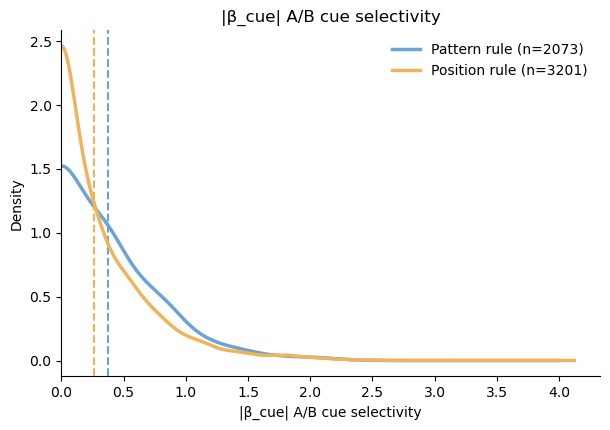

,test,n,pattern_median,position_median,position_minus_pattern,direction,p,stars
0,paired Wilcoxon on mouse medians,10,0.362537,0.284807,-0.126489,Pattern > Position,0.027344,*


[Conclusion] |β_cue| A/B cue selectivity: Pattern > Position, p=0.0273, *, test=paired Wilcoxon on mouse medians.


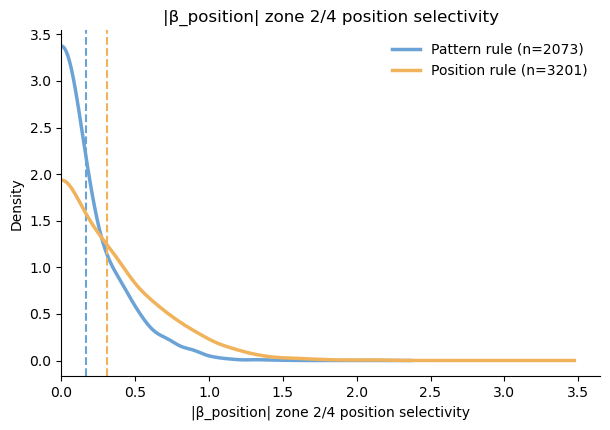

,test,n,pattern_median,position_median,position_minus_pattern,direction,p,stars
0,paired Wilcoxon on mouse medians,10,0.184133,0.306718,0.07789,Position > Pattern,0.064453,n.s.


[Conclusion] |β_position| zone 2/4 position selectivity: Position > Pattern, p=0.0645, n.s., test=paired Wilcoxon on mouse medians.


In [ ]:
cue_plot = plot_metric_distribution(
    result["coef_df"],
    metric="cue",
    analysis_mode="mixed",
    c_group="mixed",
    bw_adjust=1.0,
    fill=False,
)

cue_plot = plot_metric_distribution(
    result["coef_df"],
    metric="position",
    analysis_mode="mixed",
    c_group="mixed",
    bw_adjust=1.0,
    fill=False,
)



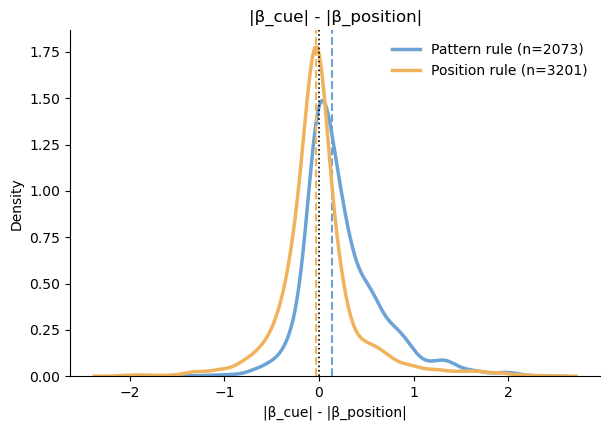

,test,n,pattern_median,position_median,position_minus_pattern,direction,p,stars
0,paired Wilcoxon on mouse medians,10,0.111304,-0.035936,-0.137359,Pattern > Position,0.001953,**


[Conclusion] |β_cue| - |β_position|: Pattern > Position, p=0.00195, **, test=paired Wilcoxon on mouse medians.


{'df':                mouse_id                                          file_path  \
 0       HP01_2024_12_14  /home/wangym/code/ZhaoLab-analysis-python/data...   
 1       HP01_2024_12_14  /home/wangym/code/ZhaoLab-analysis-python/data...   
 2       HP01_2024_12_14  /home/wangym/code/ZhaoLab-analysis-python/data...   
 3       HP01_2024_12_14  /home/wangym/code/ZhaoLab-analysis-python/data...   
 4       HP01_2024_12_14  /home/wangym/code/ZhaoLab-analysis-python/data...   
 ...                 ...                                                ...   
 20269  HPC14_2025_05_22  /home/wangym/code/ZhaoLab-analysis-python/data...   
 20270  HPC14_2025_05_22  /home/wangym/code/ZhaoLab-analysis-python/data...   
 20271  HPC14_2025_05_22  /home/wangym/code/ZhaoLab-analysis-python/data...   
 20272  HPC14_2025_05_22  /home/wangym/code/ZhaoLab-analysis-python/data...   
 20273  HPC14_2025_05_22  /home/wangym/code/ZhaoLab-analysis-python/data...   
 
                                   file_name

In [22]:
plot_metric_distribution(
    result["coef_df"],
    metric="balance",
    analysis_mode="mixed",
    c_group="mixed",
)